# HR Workforce Analytics

## 1. Project Context & Business Problem

This project examines workforce data to identify organisational, workforce, and employee-level factors associated with employee performance, productivity, and workforce stability.

The analysis is designed to move beyond descriptive HR reporting by investigating where workforce outcomes differ across employee segments, which characteristics are associated with those differences, and what the evidence may imply for workforce management and planning.

### 1.1 Business Problem

Organisations can hold substantial employee data without having a sufficiently detailed understanding of the workforce patterns contained within it.

This analysis therefore examines employee performance, productivity, workforce characteristics, and related outcomes to identify meaningful patterns that can support evidence-based workforce decisions.

### 1.2 Analytical Questions

The analysis will investigate:

- How is the workforce distributed across key employee and organisational characteristics?
- What patterns exist in employee performance and productivity?
- Which workforce characteristics are associated with differences in performance and productivity?
- Are there identifiable employee segments with materially different workforce outcomes?
- What relationships between employee characteristics and outcomes warrant further statistical investigation?
- What practical implications can be drawn from the evidence?

### 1.3 Scope and Limitations

The analysis is restricted to the variables and observations available in the supplied dataset.

Relationships identified in the analysis will be interpreted as associations unless the available evidence supports a stronger conclusion. The analysis will not make causal claims from observational data alone.

Data-quality limitations, missing information, measurement issues, and analytical assumptions will be documented as they are identified.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("HR Workforce Analytics environment is working.")

HR Workforce Analytics environment is working.


## 2. Dataset Overview & Data Inventory

This section establishes the structure and analytical scope of the dataset before any transformation or statistical analysis is performed.

The objective is to understand what information is available, how the variables are organised, which fields can support the business questions defined above, and whether the dataset presents any immediate data-quality or methodological concerns.

The dataset will be assessed at workbook, table, and variable level before decisions are made regarding cleaning, transformation, or modelling.

### 2.1 Workbook Structure

In [2]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/raw/Onyx Data - DataDNA Dataset Challenge - Employee Performance and Productivity Dataset - October 2024.xlsx")

excel = pd.ExcelFile(DATA_PATH)

print("Workbook sheets:")
for sheet in excel.sheet_names:
    print(f"- {sheet}")

Workbook sheets:
- Onyx Data - DataDNA Dataset Cha
- Data Dictionary


### 2.2 Dataset Dimensions & Initial Structure

The primary worksheet contains the employee-level observations used for the analysis. This section establishes the dimensionality of the dataset and provides an initial assessment of its structure before any cleaning or transformation is performed.

In [3]:
for i, sheet in enumerate(excel.sheet_names):
    print(i, repr(sheet))

0 'Onyx Data - DataDNA Dataset Cha'
1 'Data Dictionary'


In [4]:
# Load the primary employee dataset

DATA_SHEET = "Onyx Data - DataDNA Dataset Cha"

df = pd.read_excel(
    DATA_PATH,
    sheet_name=DATA_SHEET
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

Rows: 100,000
Columns: 20


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,False


### 2.3 Variable Inventory

The primary dataset contains 20 employee-level variables covering workforce demographics, organisational characteristics, employment history, compensation, workload, productivity, development, satisfaction, and resignation status.

The variables will be classified according to their analytical role before the data-quality and transformation stages begin.

### 2.3.1 Variable Classification

In [5]:
# Inspect variables, data types, and completeness

variable_inventory = pd.DataFrame({
    "Variable": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Unique_Values": df.nunique().values
})

variable_inventory["Completeness_%"] = (
    variable_inventory["Non_Null"] / len(df) * 100
).round(2)

display(variable_inventory)

,Variable,Data_Type,Non_Null,Missing,Unique_Values,Completeness_%
0,Employee_ID,int64,100000,0,100000,100.0
1,Department,str,100000,0,9,100.0
2,Gender,str,100000,0,3,100.0
3,Age,int64,100000,0,39,100.0
4,Job_Title,str,100000,0,7,100.0
5,Hire_Date,datetime64[us],100000,0,3650,100.0
6,Years_At_Company,int64,100000,0,11,100.0
7,Education_Level,str,100000,0,4,100.0
8,Performance_Score,int64,100000,0,5,100.0
9,Monthly_Salary,int64,100000,0,28,100.0


### 2.4 Data Dictionary

The workbook provides a dedicated data dictionary containing definitions for the variables in the employee dataset. These definitions will be used to establish the analytical meaning and measurement characteristics of each field before further analysis.

### 2.4.1 Data Dictionary Inspection

In [6]:
# Load and inspect the supplied data dictionary

data_dictionary = pd.read_excel(
    DATA_PATH,
    sheet_name="Data Dictionary"
)

print(f"Rows: {data_dictionary.shape[0]:,}")
print(f"Columns: {data_dictionary.shape[1]:,}")

display(data_dictionary)

Rows: 22
Columns: 1


,Employee_ID: Unique identifier for each employee.
0,Department: The department in which the employ...
1,"Gender: Gender of the employee (Male, Female, ..."
2,Age: Employee's age (between 22 and 60).
3,Job_Title: The role held by the employee (e.g....
4,Hire_Date: The date the employee was hired.
5,Years_At_Company: The number of years the empl...
6,Education_Level: Highest educational qualifica...
7,Performance_Score: Employee's performance rati...
8,Monthly_Salary: The employee's monthly salary ...
9,Work_Hours_Per_Week: Number of hours worked pe...


### 2.4.2 Analytical Variable Inventory

The supplied data dictionary defines the fields used in the employee dataset. For analytical purposes, the variables can be grouped into five dimensions:

| Analytical Dimension | Variables |
|---|---|
| Employee Profile | Employee_ID, Gender, Age, Education_Level |
| Organisational Structure | Department, Job_Title, Team_Size |
| Employment & Career History | Hire_Date, Years_At_Company, Promotions |
| Performance & Productivity | Performance_Score, Projects_Handled, Work_Hours_Per_Week, Overtime_Hours |
| Workforce Experience & Outcomes | Monthly_Salary, Sick_Days, Remote_Work_Frequency, Training_Hours, Employee_Satisfaction_Score, Resigned |

This classification provides the analytical framework for subsequent workforce segmentation, performance analysis, productivity analysis, and resignation analysis.

### 2.4.3 Variable Definitions

In [7]:
# Clean and display the supplied data dictionary

dictionary_rows = (
    data_dictionary.iloc[:, 0]
    .dropna()
    .astype(str)
)

dictionary_rows = dictionary_rows[
    ~dictionary_rows.str.startswith("Dataset Source", na=False)
]

variable_definitions = pd.DataFrame(
    [row.split(":", 1) for row in dictionary_rows if ":" in row],
    columns=["Variable", "Definition"]
)

variable_definitions["Variable"] = variable_definitions["Variable"].str.strip()
variable_definitions["Definition"] = variable_definitions["Definition"].str.strip()

display(variable_definitions)

,Variable,Definition
0,Department,The department in which the employee works (e....
1,Gender,"Gender of the employee (Male, Female, Other)."
2,Age,Employee's age (between 22 and 60).
3,Job_Title,"The role held by the employee (e.g., Manager, ..."
4,Hire_Date,The date the employee was hired.
5,Years_At_Company,The number of years the employee has been work...
6,Education_Level,Highest educational qualification (High School...
7,Performance_Score,Employee's performance rating (1 to 5 scale).
8,Monthly_Salary,"The employee's monthly salary in USD, correlat..."
9,Work_Hours_Per_Week,Number of hours worked per week.


## 3. Data Quality & Integrity Assessment

Before undertaking statistical or business analysis, the dataset will undergo a structured quality assessment.

The assessment will examine not only missing observations, but also duplicate records, uniqueness constraints, valid ranges, categorical consistency, temporal consistency, and logical relationships between variables.

A dataset containing no missing values cannot automatically be considered analytically reliable; therefore, each quality dimension will be assessed independently and any anomalies will be documented before transformation.

### 3.1 Record-Level Integrity

In [8]:
# Assess record-level integrity and identifier uniqueness

quality_summary = {
    "Total records": len(df),
    "Total variables": df.shape[1],
    "Duplicate rows": df.duplicated().sum(),
    "Duplicate Employee_IDs": df["Employee_ID"].duplicated().sum(),
    "Unique Employee_IDs": df["Employee_ID"].nunique(),
}

for metric, value in quality_summary.items():
    print(f"{metric}: {value:,}")

Total records: 100,000
Total variables: 20
Duplicate rows: 0
Duplicate Employee_IDs: 0
Unique Employee_IDs: 100,000


### 3.2 Numerical Range Validation

In [9]:
# Validate numerical variables against the definitions supplied in the data dictionary

range_checks = {
    "Age": (22, 60),
    "Performance_Score": (1, 5),
    "Employee_Satisfaction_Score": (1.0, 5.0),
    "Remote_Work_Frequency": (0, 100),
    "Years_At_Company": (0, None),
    "Monthly_Salary": (0, None),
    "Work_Hours_Per_Week": (0, None),
    "Projects_Handled": (0, None),
    "Overtime_Hours": (0, None),
    "Sick_Days": (0, None),
    "Team_Size": (1, None),
    "Training_Hours": (0, None),
    "Promotions": (0, None),
}

range_results = []

for variable, (lower, upper) in range_checks.items():
    series = df[variable]

    below_lower = (series < lower).sum() if lower is not None else 0
    above_upper = (series > upper).sum() if upper is not None else 0

    range_results.append({
        "Variable": variable,
        "Minimum": series.min(),
        "Maximum": series.max(),
        "Below_Lower_Bound": below_lower,
        "Above_Upper_Bound": above_upper
    })

range_results = pd.DataFrame(range_results)

display(range_results)

,Variable,Minimum,Maximum,Below_Lower_Bound,Above_Upper_Bound
0,Age,22.0,60.0,0,0
1,Performance_Score,1.0,5.0,0,0
2,Employee_Satisfaction_Score,1.0,5.0,0,0
3,Remote_Work_Frequency,0.0,100.0,0,0
4,Years_At_Company,0.0,10.0,0,0
5,Monthly_Salary,3850.0,9000.0,0,0
6,Work_Hours_Per_Week,30.0,60.0,0,0
7,Projects_Handled,0.0,49.0,0,0
8,Overtime_Hours,0.0,29.0,0,0
9,Sick_Days,0.0,14.0,0,0


### 3.3 Categorical Integrity

Categorical fields will be assessed for unexpected values, inconsistent labels, and unusually sparse categories. This is particularly important before segmentation and group-level comparisons.

In [10]:
# Inspect categorical variables and their observed categories

categorical_columns = [
    "Department",
    "Gender",
    "Job_Title",
    "Education_Level",
    "Resigned"
]

for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(column)
    print(f"{'=' * 60}")
    print(df[column].value_counts(dropna=False))


Department
Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64

Gender
Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64

Job_Title
Job_Title
Specialist    14507
Manager       14325
Technician    14285
Analyst       14261
Engineer      14217
Consultant    14210
Developer     14195
Name: count, dtype: int64

Education_Level
Education_Level
Bachelor       50041
High School    30004
Master         14904
PhD             5051
Name: count, dtype: int64

Resigned
Resigned
False    89990
True     10010
Name: count, dtype: int64


### 3.4 Temporal Integrity

Hire dates will be examined for their temporal coverage and consistency with recorded tenure. This provides an additional integrity check because employment duration should have a logical relationship with the hiring date.

In [11]:
# Examine the temporal coverage of employee hire dates

print(f"Earliest hire date: {df['Hire_Date'].min()}")
print(f"Latest hire date:   {df['Hire_Date'].max()}")

print("\nHire years:")
display(df["Hire_Date"].dt.year.value_counts().sort_index())

Earliest hire date: 2014-09-07 08:03:05.556000
Latest hire date:   2024-09-03 08:03:05.556000

Hire years:


Hire_Date
2014     3097
2015     9886
2016     9874
2017    10004
2018    10005
2019     9936
2020    10096
2021    10094
2022    10145
2023     9973
2024     6890
Name: count, dtype: int64

### 3.5 Workforce Logic & Consistency Checks

Range validation establishes whether individual values fall within their expected boundaries, but workforce data also contains relationships between variables that should be logically coherent.

This assessment examines relationships between tenure, hire date, age, workload, and employment outcomes to identify records that may be mathematically valid but analytically questionable.

In [12]:
# Internal consistency checks

from datetime import datetime

REFERENCE_DATE = pd.Timestamp("2024-09-07")

consistency_checks = pd.DataFrame({
    "Check": [
        "Years_At_Company exceeds observed employment period",
        "Years_At_Company exceeds employee age",
        "Hire date occurs after reference date",
        "Work hours below 30 per week",
        "Work hours above 60 per week",
        "Negative overtime hours",
        "Negative sick days",
        "Negative promotions"
    ],
    "Records_Flagged": [
        (
            df["Years_At_Company"] >
            ((REFERENCE_DATE - df["Hire_Date"]).dt.days / 365.25)
        ).sum(),
        (
            df["Years_At_Company"] > df["Age"]
        ).sum(),
        (
            df["Hire_Date"] > REFERENCE_DATE
        ).sum(),
        (
            df["Work_Hours_Per_Week"] < 30
        ).sum(),
        (
            df["Work_Hours_Per_Week"] > 60
        ).sum(),
        (
            df["Overtime_Hours"] < 0
        ).sum(),
        (
            df["Sick_Days"] < 0
        ).sum(),
        (
            df["Promotions"] < 0
        ).sum()
    ]
})

display(consistency_checks)

,Check,Records_Flagged
0,Years_At_Company exceeds observed employment p...,64
1,Years_At_Company exceeds employee age,0
2,Hire date occurs after reference date,0
3,Work hours below 30 per week,0
4,Work hours above 60 per week,0
5,Negative overtime hours,0
6,Negative sick days,0
7,Negative promotions,0


### 3.6 Categorical Distribution Review

The categorical variables are reviewed individually to establish their observed levels and identify categories that may require consolidation or further investigation during feature engineering.

In [13]:
# Display complete distributions for the remaining categorical variables

for column in ["Job_Title", "Education_Level"]:
    print(f"\n{column}")
    print("-" * 40)
    display(
        df[column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name="Count")
    )


Job_Title
----------------------------------------


,Job_Title,Count
0,Specialist,14507
1,Manager,14325
2,Technician,14285
3,Analyst,14261
4,Engineer,14217
5,Consultant,14210
6,Developer,14195



Education_Level
----------------------------------------


,Education_Level,Count
0,Bachelor,50041
1,High School,30004
2,Master,14904
3,PhD,5051


### 3.7 Tenure Consistency Investigation

The initial integrity assessment identified 64 records where recorded tenure exceeds the exact elapsed time between the employee's hire date and the analysis reference date.

Because tenure is recorded in whole years while hire dates contain precise dates and times, these observations will be investigated before determining whether they represent genuine inconsistencies or an expected rounding convention.

In [14]:
# Investigate records where recorded tenure exceeds elapsed tenure

tenure_check = df.copy()

tenure_check["Elapsed_Years"] = (
    (REFERENCE_DATE - tenure_check["Hire_Date"]).dt.days / 365.25
)

tenure_check["Tenure_Difference"] = (
    tenure_check["Years_At_Company"] - tenure_check["Elapsed_Years"]
)

tenure_flags = tenure_check[
    tenure_check["Tenure_Difference"] > 0
].sort_values(
    "Tenure_Difference",
    ascending=False
)

print(f"Records flagged: {len(tenure_flags):,}")

display(
    tenure_flags[
        [
            "Employee_ID",
            "Hire_Date",
            "Years_At_Company",
            "Elapsed_Years",
            "Tenure_Difference"
        ]
    ].head(20)
)

Records flagged: 64


,Employee_ID,Hire_Date,Years_At_Company,Elapsed_Years,Tenure_Difference
56719,56720,2014-09-07 08:03:05.556,10,9.998631,0.001369
66661,66662,2014-09-07 08:03:05.556,10,9.998631,0.001369
51602,51603,2014-09-07 08:03:05.556,10,9.998631,0.001369
54944,54945,2014-09-07 08:03:05.556,10,9.998631,0.001369
55759,55760,2014-09-07 08:03:05.556,10,9.998631,0.001369
58397,58398,2014-09-07 08:03:05.556,10,9.998631,0.001369
60306,60307,2014-09-07 08:03:05.556,10,9.998631,0.001369
60739,60740,2014-09-07 08:03:05.556,10,9.998631,0.001369
61879,61880,2014-09-07 08:03:05.556,10,9.998631,0.001369
61943,61944,2014-09-07 08:03:05.556,10,9.998631,0.001369


### 3.7.1 Tenure Difference Distribution

In [15]:
# Quantify the magnitude of the tenure discrepancies

print("Tenure difference summary:")
display(
    tenure_flags["Tenure_Difference"]
    .describe()
    .to_frame()
    .T
)

print("\nMaximum tenure difference:")
print(f"{tenure_flags['Tenure_Difference'].max():.3f} years")

Tenure difference summary:


,count,mean,std,min,25%,50%,75%,max
Tenure_Difference,64.0,0.001155,0.00032,0.000684,0.000684,0.001369,0.001369,0.001369



Maximum tenure difference:
0.001 years


# 4. Workforce Descriptive Analysis

This section establishes the demographic, organisational and employment profile of the workforce. The analysis examines workforce composition across departments, job roles, gender and education, followed by measures of age, tenure, compensation, workload, development and employee experience.

The objective is to identify structural patterns and material differences within the workforce that can inform subsequent analysis of employee performance, engagement and resignation.

## 4.1 Workforce Composition

We begin by examining how the 100,000 employees are distributed across departments, job titles, gender and education levels. These variables provide the organisational context required for interpreting subsequent workforce outcomes.

In [16]:
# Workforce composition: department, job title, gender and education

composition_variables = [
    "Department",
    "Job_Title",
    "Gender",
    "Education_Level"
]

for variable in composition_variables:
    print("=" * 70)
    print(variable)
    print("=" * 70)

    composition = (
        df[variable]
        .value_counts()
        .rename_axis(variable)
        .reset_index(name="Employee_Count")
    )

    composition["Workforce_Share_%"] = (
        composition["Employee_Count"]
        / len(df)
        * 100
    ).round(2)

    display(composition)
    print()

Department


,Department,Employee_Count,Workforce_Share_%
0,Marketing,11216,11.22
1,Finance,11200,11.20
2,Operations,11181,11.18
3,IT,11131,11.13
4,Sales,11122,11.12
5,Legal,11118,11.12
6,Customer Support,11116,11.12
7,HR,10960,10.96
8,Engineering,10956,10.96



Job_Title


,Job_Title,Employee_Count,Workforce_Share_%
0,Specialist,14507,14.51
1,Manager,14325,14.32
2,Technician,14285,14.28
3,Analyst,14261,14.26
4,Engineer,14217,14.22
5,Consultant,14210,14.21
6,Developer,14195,14.19



Gender


,Gender,Employee_Count,Workforce_Share_%
0,Male,48031,48.03
1,Female,48001,48.00
2,Other,3968,3.97



Education_Level


,Education_Level,Employee_Count,Workforce_Share_%
0,Bachelor,50041,50.04
1,High School,30004,30.00
2,Master,14904,14.90
3,PhD,5051,5.05


## 4.2 Workforce Demographic & Employment Profile

This subsection examines the numerical characteristics of the workforce, focusing on age, organisational tenure, compensation, working hours, project workload, overtime, training, promotions and employee satisfaction.

Rather than relying solely on overall averages, the analysis evaluates the distribution and spread of each measure to identify differences in workforce experience, workload and employee conditions that may warrant deeper investigation.

In [17]:
# Core workforce profile: distributional statistics

profile_variables = [
    "Age",
    "Years_At_Company",
    "Monthly_Salary",
    "Work_Hours_Per_Week",
    "Projects_Handled",
    "Overtime_Hours",
    "Sick_Days",
    "Training_Hours",
    "Promotions",
    "Employee_Satisfaction_Score"
]

workforce_profile = (
    df[profile_variables]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "Variable"})
)

workforce_profile["IQR"] = (
    workforce_profile["75%"] - workforce_profile["25%"]
).round(2)

workforce_profile = workforce_profile[
    [
        "Variable",
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "IQR"
    ]
].round(2)

display(workforce_profile)

,Variable,count,mean,std,min,25%,50%,75%,max,IQR
0,Age,100000.0,41.03,11.24,22.0,31.00,41.0,51.00,60.0,20.00
1,Years_At_Company,100000.0,4.48,2.87,0.0,2.00,4.0,7.00,10.0,5.00
2,Monthly_Salary,100000.0,6403.21,1372.51,3850.0,5250.00,6500.0,7500.00,9000.0,2250.00
3,Work_Hours_Per_Week,100000.0,44.96,8.94,30.0,37.00,45.0,53.00,60.0,16.00
4,Projects_Handled,100000.0,24.43,14.47,0.0,12.00,24.0,37.00,49.0,25.00
5,Overtime_Hours,100000.0,14.51,8.66,0.0,7.00,15.0,22.00,29.0,15.00
6,Sick_Days,100000.0,7.01,4.33,0.0,3.00,7.0,11.00,14.0,8.00
7,Training_Hours,100000.0,49.51,28.89,0.0,25.00,49.0,75.00,99.0,50.00
8,Promotions,100000.0,1.00,0.82,0.0,0.00,1.0,2.00,2.0,2.00
9,Employee_Satisfaction_Score,100000.0,3.00,1.15,1.0,2.01,3.0,3.99,5.0,1.98


### 4.2.1 Workforce Profile by Key Employment Measures

The summary statistics provide an initial view of the central tendency, variability and range of major workforce measures. The median and interquartile range are included alongside the mean to distinguish typical employee conditions from variation across the workforce.

In [18]:
# Median and distributional spread for selected workforce measures

key_measures = [
    "Age",
    "Years_At_Company",
    "Monthly_Salary",
    "Work_Hours_Per_Week",
    "Projects_Handled",
    "Overtime_Hours",
    "Sick_Days",
    "Training_Hours",
    "Promotions",
    "Employee_Satisfaction_Score"
]

distribution_summary = pd.DataFrame({
    "Measure": key_measures,
    "Mean": [df[col].mean() for col in key_measures],
    "Median": [df[col].median() for col in key_measures],
    "Std_Dev": [df[col].std() for col in key_measures],
    "P25": [df[col].quantile(0.25) for col in key_measures],
    "P75": [df[col].quantile(0.75) for col in key_measures]
})

distribution_summary["Mean_Median_Gap"] = (
    distribution_summary["Mean"]
    - distribution_summary["Median"]
).round(2)

display(distribution_summary.round(2))

,Measure,Mean,Median,Std_Dev,P25,P75,Mean_Median_Gap
0,Age,41.03,41.0,11.24,31.00,51.00,0.03
1,Years_At_Company,4.48,4.0,2.87,2.00,7.00,0.48
2,Monthly_Salary,6403.21,6500.0,1372.51,5250.00,7500.00,-96.79
3,Work_Hours_Per_Week,44.96,45.0,8.94,37.00,53.00,-0.04
4,Projects_Handled,24.43,24.0,14.47,12.00,37.00,0.43
5,Overtime_Hours,14.51,15.0,8.66,7.00,22.00,-0.49
6,Sick_Days,7.01,7.0,4.33,3.00,11.00,0.01
7,Training_Hours,49.51,49.0,28.89,25.00,75.00,0.51
8,Promotions,1.00,1.0,0.82,0.00,2.00,-0.00
9,Employee_Satisfaction_Score,3.00,3.0,1.15,2.01,3.99,-0.00


## 4.3 Departmental Workforce Profile

Workforce-level averages can conceal meaningful differences between organisational units. This subsection compares departments across tenure, compensation, working hours, project workload, overtime, training, performance and employee satisfaction.

The objective is to establish whether departments operate under materially different workforce conditions before examining the factors associated with employee outcomes.

In [19]:
# Department-level workforce profile

department_profile = (
    df.groupby("Department")
      .agg(
          Employee_Count=("Employee_ID", "count"),
          Avg_Age=("Age", "mean"),
          Avg_Tenure=("Years_At_Company", "mean"),
          Median_Salary=("Monthly_Salary", "median"),
          Avg_Salary=("Monthly_Salary", "mean"),
          Avg_Work_Hours=("Work_Hours_Per_Week", "mean"),
          Avg_Projects=("Projects_Handled", "mean"),
          Avg_Overtime=("Overtime_Hours", "mean"),
          Avg_Training=("Training_Hours", "mean"),
          Avg_Performance=("Performance_Score", "mean"),
          Avg_Satisfaction=("Employee_Satisfaction_Score", "mean")
      )
      .reset_index()
)

department_profile["Workforce_Share_%"] = (
    department_profile["Employee_Count"]
    / len(df)
    * 100
)

department_profile = department_profile[
    [
        "Department",
        "Employee_Count",
        "Workforce_Share_%",
        "Avg_Age",
        "Avg_Tenure",
        "Avg_Salary",
        "Median_Salary",
        "Avg_Work_Hours",
        "Avg_Projects",
        "Avg_Overtime",
        "Avg_Training",
        "Avg_Performance",
        "Avg_Satisfaction"
    ]
].round(2)

display(
    department_profile.sort_values(
        "Avg_Salary",
        ascending=False
    ).reset_index(drop=True)
)

,Department,Employee_Count,Workforce_Share_%,Avg_Age,Avg_Tenure,Avg_Salary,Median_Salary,Avg_Work_Hours,Avg_Projects,Avg_Overtime,Avg_Training,Avg_Performance,Avg_Satisfaction
0,Engineering,10956,10.96,41.12,4.49,6417.25,6500.0,45.07,24.42,14.59,50.00,3.02,3.00
1,IT,11131,11.13,41.08,4.44,6414.60,6500.0,44.93,24.54,14.67,49.18,3.00,3.02
2,Sales,11122,11.12,40.88,4.47,6413.15,6500.0,45.01,24.71,14.51,49.29,2.99,2.99
3,Operations,11181,11.18,41.12,4.47,6412.31,6500.0,44.97,24.30,14.52,49.10,3.01,3.03
4,Customer Support,11116,11.12,40.95,4.49,6403.88,6500.0,44.91,24.43,14.38,49.53,3.00,2.97
5,HR,10960,10.96,40.98,4.47,6400.36,6500.0,44.93,24.20,14.58,49.62,3.00,3.00
6,Finance,11200,11.20,41.02,4.48,6398.58,6500.0,44.89,24.41,14.34,49.76,2.98,3.00
7,Legal,11118,11.12,40.98,4.47,6391.28,6500.0,45.01,24.21,14.55,49.78,2.98,2.99
8,Marketing,11216,11.22,41.13,4.50,6377.86,6500.0,44.89,24.66,14.48,49.30,2.98,2.99


### 4.3.1 Departmental Variation

The departmental profile is used to identify areas where workforce conditions differ meaningfully from the overall workforce. Particular attention is given to compensation, workload, overtime, development, performance and satisfaction, as differences in these dimensions may become important when investigating productivity and employee retention.

In [20]:
# Measure the spread between departments for key workforce indicators

department_variation = pd.DataFrame({
    "Measure": [
        "Avg Salary",
        "Avg Tenure",
        "Avg Work Hours",
        "Avg Projects",
        "Avg Overtime",
        "Avg Training",
        "Avg Performance",
        "Avg Satisfaction"
    ],
    "Minimum_Department_Value": [
        department_profile["Avg_Salary"].min(),
        department_profile["Avg_Tenure"].min(),
        department_profile["Avg_Work_Hours"].min(),
        department_profile["Avg_Projects"].min(),
        department_profile["Avg_Overtime"].min(),
        department_profile["Avg_Training"].min(),
        department_profile["Avg_Performance"].min(),
        department_profile["Avg_Satisfaction"].min()
    ],
    "Maximum_Department_Value": [
        department_profile["Avg_Salary"].max(),
        department_profile["Avg_Tenure"].max(),
        department_profile["Avg_Work_Hours"].max(),
        department_profile["Avg_Projects"].max(),
        department_profile["Avg_Overtime"].max(),
        department_profile["Avg_Training"].max(),
        department_profile["Avg_Performance"].max(),
        department_profile["Avg_Satisfaction"].max()
    ]
})

department_variation["Department_Range"] = (
    department_variation["Maximum_Department_Value"]
    - department_variation["Minimum_Department_Value"]
)

display(department_variation.round(2))

,Measure,Minimum_Department_Value,Maximum_Department_Value,Department_Range
0,Avg Salary,6377.86,6417.25,39.39
1,Avg Tenure,4.44,4.50,0.06
2,Avg Work Hours,44.89,45.07,0.18
3,Avg Projects,24.20,24.71,0.51
4,Avg Overtime,14.34,14.67,0.33
5,Avg Training,49.10,50.00,0.90
6,Avg Performance,2.98,3.02,0.04
7,Avg Satisfaction,2.97,3.03,0.06


### 4.3.2 Departmental Workforce Comparison

The departmental analysis indicates that workforce conditions are broadly consistent across organisational units. Although small differences exist in compensation, workload, training and employee experience, the magnitude of these differences is limited relative to the overall workforce.

To make this pattern more interpretable, the following visual comparison focuses on the measures most relevant to workforce management: compensation, workload, overtime, performance and satisfaction.

The purpose is not to rank departments artificially, but to determine whether department-level differences are large enough to warrant further investigation.

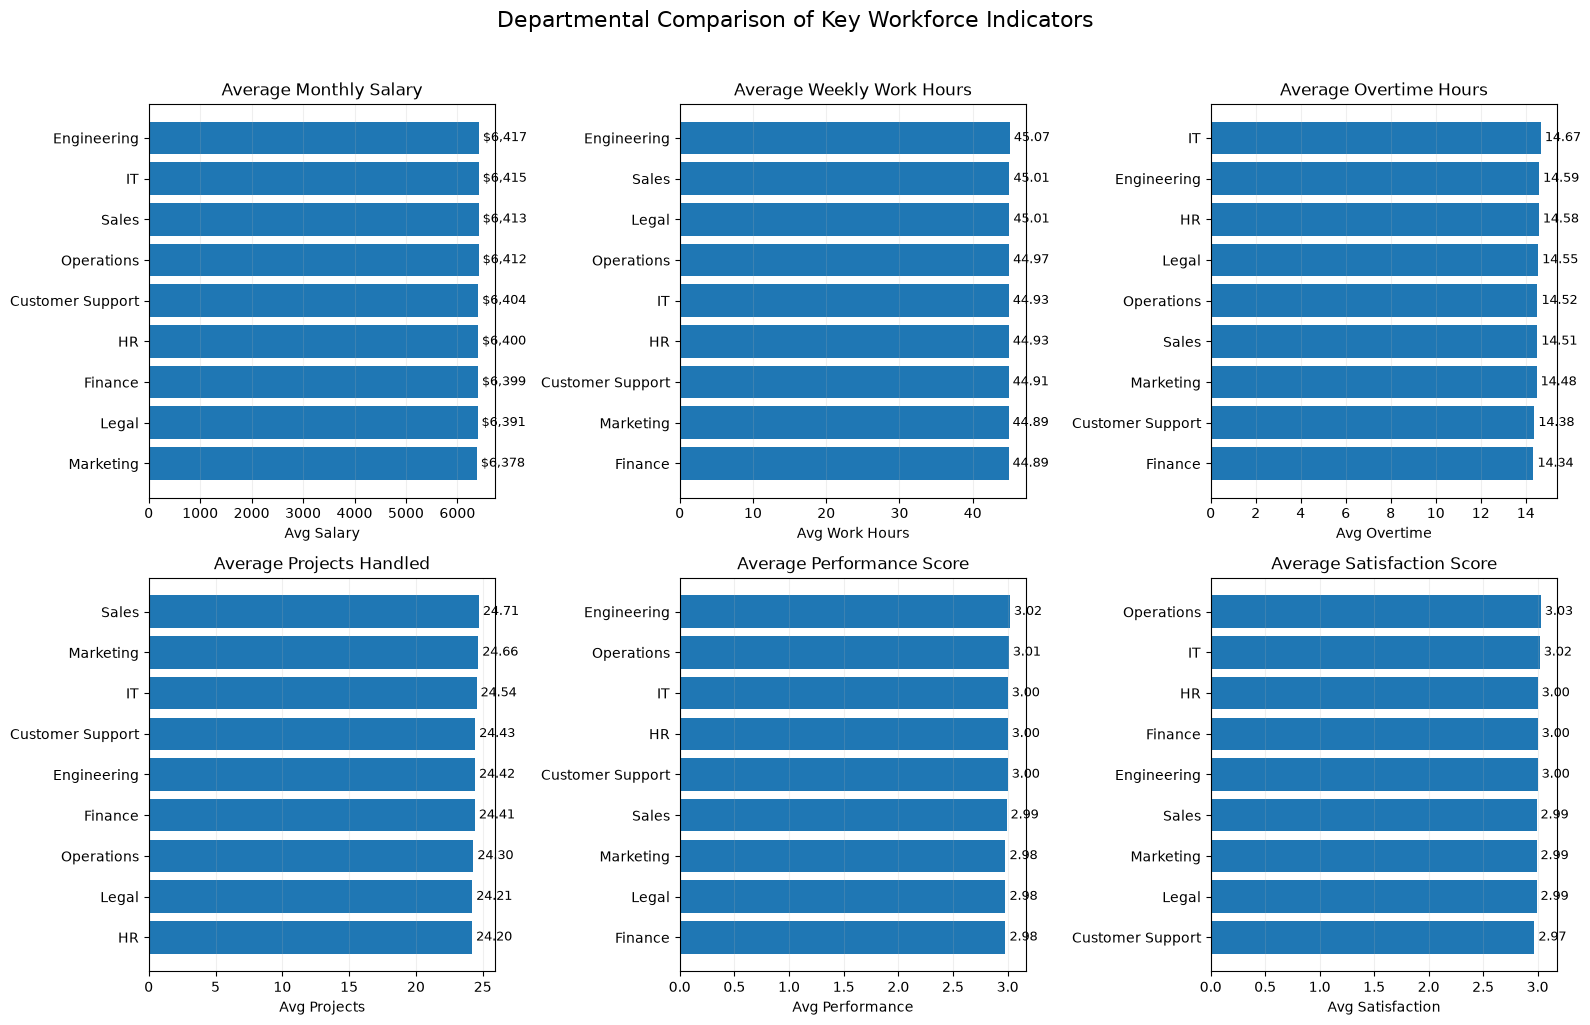

Chart saved to: ../visuals/4.3.2_departmental_workforce_comparison.png


In [21]:
# 4.3.2 Departmental Workforce Comparison
# Create and save the departmental workforce comparison chart

from pathlib import Path
import matplotlib.pyplot as plt

# Define the project visuals directory
VISUALS_DIR = Path("../visuals")
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

# Set Department as the index for plotting
department_comparison = department_profile.set_index("Department")

# Workforce indicators to compare
comparison_metrics = [
    ("Avg_Salary", "Average Monthly Salary", "$"),
    ("Avg_Work_Hours", "Average Weekly Work Hours", ""),
    ("Avg_Overtime", "Average Overtime Hours", ""),
    ("Avg_Projects", "Average Projects Handled", ""),
    ("Avg_Performance", "Average Performance Score", ""),
    ("Avg_Satisfaction", "Average Satisfaction Score", "")
]

# Create the six-panel figure
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (metric, title, prefix) in zip(axes.flatten(), comparison_metrics):

    values = department_comparison[metric].sort_values()

    ax.barh(values.index, values.values)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(metric.replace("_", " "))
    ax.grid(axis="x", alpha=0.2)

    # Add values to the bars
    for y, value in enumerate(values.values):

        if prefix == "$":
            label = f"${value:,.0f}"
        else:
            label = f"{value:.2f}"

        ax.text(
            value,
            y,
            f" {label}",
            va="center",
            fontsize=9
        )

# Overall figure title
fig.suptitle(
    "Departmental Comparison of Key Workforce Indicators",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save the chart to the project's visuals folder
figure_path = VISUALS_DIR / "4.3.2_departmental_workforce_comparison.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {figure_path}")

### 4.3.3 Departmental Findings

The departmental comparison shows highly consistent workforce conditions across departments. Average salary ranges from $6,378 to $6,417, while average weekly work hours range from 44.89 to 45.07 hours. Overtime also varies only slightly, from 14.34 to 14.67 hours.

Project workload is similarly stable, ranging from 24.20 to 24.71 projects. Average performance scores range from 2.98 to 3.02, while satisfaction scores range from 2.97 to 3.03.

Overall, department-level differences are minimal across the indicators examined. This suggests that department alone is unlikely to explain substantial differences in workforce outcomes. The analysis therefore proceeds to employee-level comparisons, with particular attention to differences between employees who resigned and those who remained.

## 4.4 Attrition and Workforce Segmentation

This section examines workforce attrition by comparing employees who resigned with those who remained and identifying whether attrition is concentrated within particular employee, organisational, or job-related segments.

### 4.4.1 Resigned vs Retained Employees

To investigate workforce stability, employees are compared according to resignation status. The comparison examines demographic, employment, compensation, workload, performance, training, and satisfaction measures to identify characteristics that differ between employees who resigned and those who remained.

In [22]:
# 4.4.1 Resigned vs Retained Employees

resignation_profile = (
    df.groupby("Resigned")
      .agg(
          Employees=("Employee_ID", "count"),
          Avg_Age=("Age", "mean"),
          Avg_Tenure=("Years_At_Company", "mean"),
          Avg_Salary=("Monthly_Salary", "mean"),
          Avg_Work_Hours=("Work_Hours_Per_Week", "mean"),
          Avg_Projects=("Projects_Handled", "mean"),
          Avg_Overtime=("Overtime_Hours", "mean"),
          Avg_Sick_Days=("Sick_Days", "mean"),
          Avg_Training=("Training_Hours", "mean"),
          Avg_Promotions=("Promotions", "mean"),
          Avg_Performance=("Performance_Score", "mean"),
          Avg_Satisfaction=("Employee_Satisfaction_Score", "mean")
      )
      .rename(index={False: "Retained", True: "Resigned"})
)

resignation_profile.round(2)

,Employees,Avg_Age,Avg_Tenure,Avg_Salary,Avg_Work_Hours,Avg_Projects,Avg_Overtime,Avg_Sick_Days,Avg_Training,Avg_Promotions,Avg_Performance,Avg_Satisfaction
Resigned,,,,,,,,,,,,
Retained,89990,41.02,4.48,6403.91,44.96,24.44,14.51,7.01,49.49,1.0,3.00,3.00
Resigned,10010,41.15,4.48,6396.94,44.96,24.36,14.58,7.03,49.61,1.0,2.98,2.99


### 4.4.2 Statistical Comparison of Resigned and Retained Employees

Descriptive comparisons identify differences between resigned and retained employees, but observed differences alone do not establish whether those differences are statistically meaningful.

Statistical tests are therefore applied to the continuous workforce variables to assess whether their distributions differ between the two resignation groups.

In [23]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [24]:
# 4.4.2 Statistical Comparison of Resigned and Retained Employees

from scipy.stats import ttest_ind

continuous_variables = [
    "Age",
    "Years_At_Company",
    "Monthly_Salary",
    "Work_Hours_Per_Week",
    "Projects_Handled",
    "Overtime_Hours",
    "Sick_Days",
    "Training_Hours",
    "Promotions",
    "Performance_Score",
    "Employee_Satisfaction_Score"
]

statistical_results = []

for variable in continuous_variables:

    retained = df.loc[df["Resigned"] == False, variable]
    resigned = df.loc[df["Resigned"] == True, variable]

    t_stat, p_value = ttest_ind(
        retained,
        resigned,
        equal_var=False
    )

    statistical_results.append({
        "Variable": variable,
        "Retained_Mean": retained.mean(),
        "Resigned_Mean": resigned.mean(),
        "Mean_Difference": resigned.mean() - retained.mean(),
        "T_Statistic": t_stat,
        "P_Value": p_value
    })

statistical_results = pd.DataFrame(statistical_results)

statistical_results["Significant_At_0.05"] = (
    statistical_results["P_Value"] < 0.05
)

statistical_results.round(4)

,Variable,Retained_Mean,Resigned_Mean,Mean_Difference,T_Statistic,P_Value,Significant_At_0.05
0,Age,41.0162,41.1481,0.1318,-1.1176,0.2638,False
1,Years_At_Company,4.4753,4.4828,0.0075,-0.2478,0.8043,False
2,Monthly_Salary,6403.9088,6396.9381,-6.9707,0.4832,0.6290,False
3,Work_Hours_Per_Week,44.9565,44.9608,0.0043,-0.0457,0.9636,False
4,Projects_Handled,24.4394,24.3568,-0.0826,0.5437,0.5867,False
5,Overtime_Hours,14.5080,14.5768,0.0688,-0.7536,0.4511,False
6,Sick_Days,7.0061,7.0308,0.0247,-0.5383,0.5903,False
7,Training_Hours,49.4948,49.6076,0.1128,-0.3722,0.7098,False
8,Promotions,0.9999,0.9979,-0.0020,0.2349,0.8143,False
9,Performance_Score,2.9967,2.9839,-0.0128,0.8610,0.3892,False


### 4.4.3 Effect Size Analysis

Statistical significance can identify whether differences between resignation groups are unlikely to be due to sampling variation, but it does not indicate the practical magnitude of those differences.

Cohen's d is therefore calculated for the continuous workforce variables to quantify the standardised difference between resigned and retained employees.

In [25]:
# 4.4.3 Effect Size Analysis

import numpy as np

effect_size_results = []

for variable in continuous_variables:

    retained = df.loc[df["Resigned"] == False, variable]
    resigned = df.loc[df["Resigned"] == True, variable]

    n_retained = len(retained)
    n_resigned = len(resigned)

    pooled_sd = np.sqrt(
        (
            (n_retained - 1) * retained.var()
            + (n_resigned - 1) * resigned.var()
        )
        / (n_retained + n_resigned - 2)
    )

    cohens_d = (
        resigned.mean() - retained.mean()
    ) / pooled_sd

    effect_size_results.append({
        "Variable": variable,
        "Cohens_d": cohens_d,
        "Absolute_Cohens_d": abs(cohens_d)
    })

effect_size_results = pd.DataFrame(effect_size_results)

effect_size_results.round(4)

,Variable,Cohens_d,Absolute_Cohens_d
0,Age,0.0117,0.0117
1,Years_At_Company,0.0026,0.0026
2,Monthly_Salary,-0.0051,0.0051
3,Work_Hours_Per_Week,0.0005,0.0005
4,Projects_Handled,-0.0057,0.0057
5,Overtime_Hours,0.0079,0.0079
6,Sick_Days,0.0057,0.0057
7,Training_Hours,0.0039,0.0039
8,Promotions,-0.0025,0.0025
9,Performance_Score,-0.0090,0.0090


### 4.4.4 Attrition by Workforce Segment

Attrition is examined across key categorical workforce segments to identify whether resignation is concentrated within particular departments, job titles, gender groups, education levels, or remote-work arrangements.

In [26]:
# 4.4.4 Attrition by Workforce Segment

categorical_variables = [
    "Department",
    "Job_Title",
    "Gender",
    "Education_Level",
    "Remote_Work_Frequency"
]

segment_results = []

for variable in categorical_variables:

    segment = (
        df.groupby(variable)["Resigned"]
          .agg(["count", "sum", "mean"])
          .reset_index()
    )

    segment.columns = [
        variable,
        "Employees",
        "Resigned_Employees",
        "Resignation_Rate"
    ]

    segment["Resignation_Rate"] *= 100

    segment_results.append(
        (variable, segment.sort_values("Resignation_Rate", ascending=False))
    )

for variable, result in segment_results:
    print(f"\n{'=' * 70}")
    print(variable)
    print(f"{'=' * 70}")
    display(result.round(2))


Department


,Department,Employees,Resigned_Employees,Resignation_Rate
2,Finance,11200,1180,10.54
3,HR,10960,1125,10.26
5,Legal,11118,1136,10.22
6,Marketing,11216,1125,10.03
7,Operations,11181,1121,10.03
8,Sales,11122,1104,9.93
0,Customer Support,11116,1098,9.88
1,Engineering,10956,1057,9.65
4,IT,11131,1064,9.56



Job_Title


,Job_Title,Employees,Resigned_Employees,Resignation_Rate
4,Manager,14325,1470,10.26
0,Analyst,14261,1450,10.17
1,Consultant,14210,1430,10.06
6,Technician,14285,1429,10.00
2,Developer,14195,1411,9.94
5,Specialist,14507,1427,9.84
3,Engineer,14217,1393,9.80



Gender


,Gender,Employees,Resigned_Employees,Resignation_Rate
0,Female,48001,4816,10.03
1,Male,48031,4807,10.01
2,Other,3968,387,9.75



Education_Level


,Education_Level,Employees,Resigned_Employees,Resignation_Rate
3,PhD,5051,521,10.31
0,Bachelor,50041,5003,10.00
1,High School,30004,2999,10.00
2,Master,14904,1487,9.98



Remote_Work_Frequency


,Remote_Work_Frequency,Employees,Resigned_Employees,Resignation_Rate
3,75,20173,2074,10.28
4,100,20049,2038,10.17
1,25,20235,2046,10.11
2,50,19706,1971,10.00
0,0,19837,1881,9.48


### 4.4.5 Statistical Association Between Workforce Segments and Attrition

Chi-square tests of independence are used to assess whether resignation status is statistically associated with key categorical workforce characteristics.

Cramér's V is also calculated to measure the strength of each association, since statistical significance alone may be misleading in a large dataset.

In [27]:
# 4.4.5 Statistical Association Between Workforce Segments and Attrition

from scipy.stats import chi2_contingency

categorical_variables = [
    "Department",
    "Job_Title",
    "Gender",
    "Education_Level",
    "Remote_Work_Frequency"
]

chi_square_results = []

for variable in categorical_variables:

    contingency_table = pd.crosstab(
        df[variable],
        df["Resigned"]
    )

    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(rows - 1, columns - 1))
    )

    chi_square_results.append({
        "Variable": variable,
        "Chi_Square": chi2,
        "Degrees_of_Freedom": degrees_of_freedom,
        "P_Value": p_value,
        "Cramers_V": cramers_v,
        "Significant_At_0.05": p_value < 0.05
    })

chi_square_results = pd.DataFrame(chi_square_results)

chi_square_results.round(4)

,Variable,Chi_Square,Degrees_of_Freedom,P_Value,Cramers_V,Significant_At_0.05
0,Department,9.1795,8,0.3274,0.0096,False
1,Job_Title,2.7163,6,0.8435,0.0052,False
2,Gender,0.3196,2,0.8523,0.0018,False
3,Education_Level,0.5541,3,0.9068,0.0024,False
4,Remote_Work_Frequency,8.5450,4,0.0735,0.0092,False


### 4.4.6 Attrition Rate by Workforce Segment

The resignation rates across key workforce segments are visualised to facilitate comparison of attrition patterns across departments, job titles, gender, education level, and remote-work frequency.

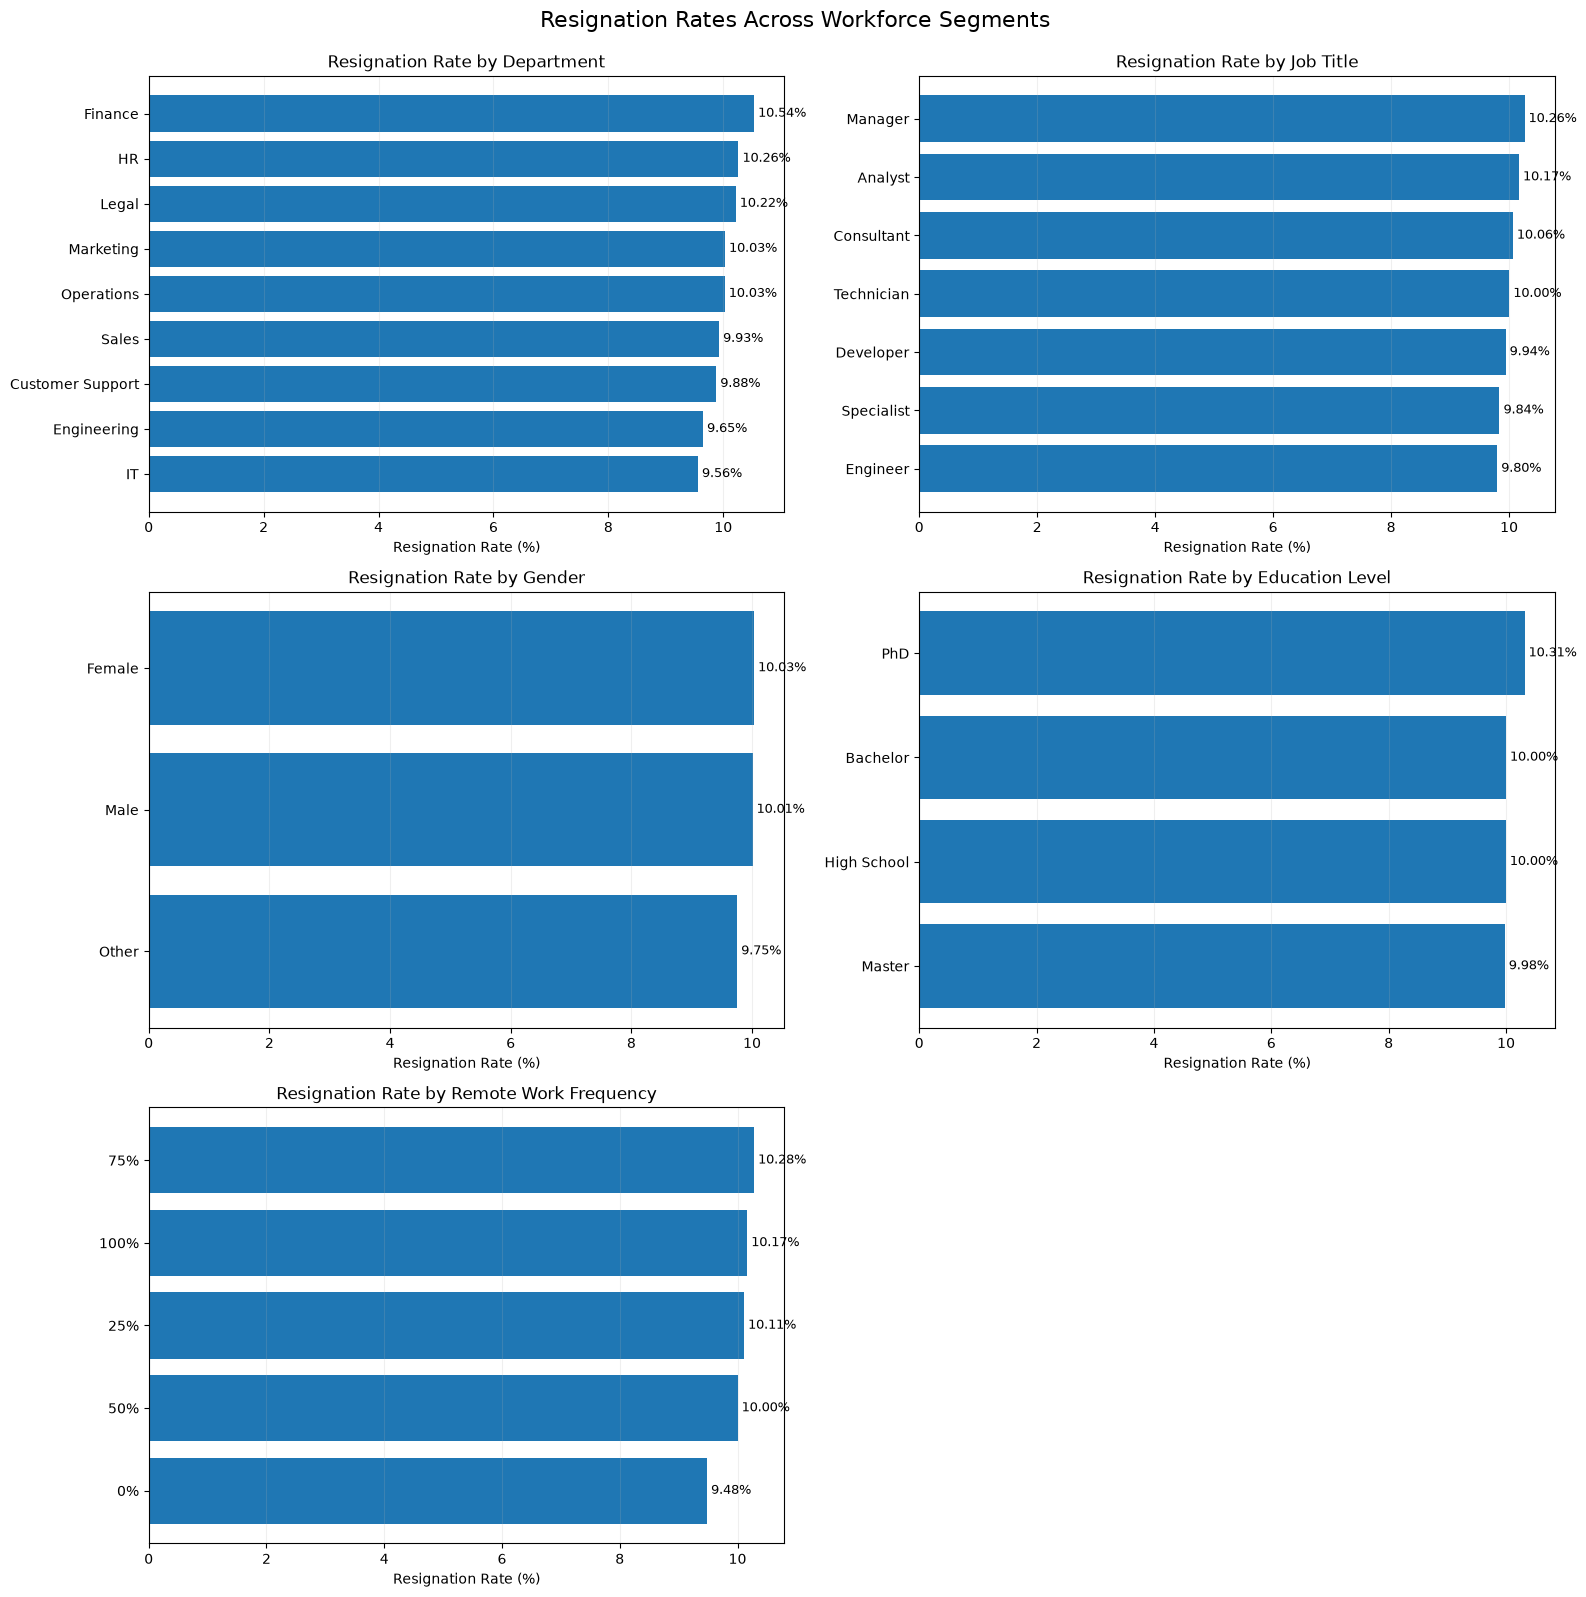

Chart saved to: ../visuals/4.4.6_attrition_rate_by_workforce_segment.png


In [28]:
# 4.4.6 Attrition Rate by Workforce Segment

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

segment_plot_data = [
    ("Department", "Resignation Rate by Department"),
    ("Job_Title", "Resignation Rate by Job Title"),
    ("Gender", "Resignation Rate by Gender"),
    ("Education_Level", "Resignation Rate by Education Level"),
    ("Remote_Work_Frequency", "Resignation Rate by Remote Work Frequency")
]

for ax, (variable, title) in zip(axes.flatten(), segment_plot_data):

    plot_data = (
        df.groupby(variable)["Resigned"]
          .mean()
          .mul(100)
          .sort_values()
    )

    labels = plot_data.index.astype(str)

    # Format remote work frequency labels
    if variable == "Remote_Work_Frequency":
        labels = [f"{float(label):.0f}%" for label in labels]

    ax.barh(labels, plot_data.values)

    ax.set_title(title)
    ax.set_xlabel("Resignation Rate (%)")
    ax.grid(axis="x", alpha=0.2)

    for y, value in enumerate(plot_data.values):
        ax.text(
            value,
            y,
            f" {value:.2f}%",
            va="center",
            fontsize=9
        )

# Remove unused subplot
axes.flatten()[-1].remove()

fig.suptitle(
    "Resignation Rates Across Workforce Segments",
    fontsize=16,
    y=0.995
)

plt.tight_layout()

figure_path = VISUALS_DIR / "4.4.6_attrition_rate_by_workforce_segment.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {figure_path}")

### 4.4.7 Attrition by Employee Segments

To identify potential concentration of attrition that may not be visible in overall averages, employees are segmented using age, tenure, salary, and satisfaction. Resignation rates are then calculated within each segment.

In [29]:
# 4.4.7 Attrition by Employee Segments

# Create employee segments

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 29, 39, 49, 59, float("inf")],
    labels=["Under 30", "30–39", "40–49", "50–59", "60+"],
    right=True
)

df["Tenure_Group"] = pd.cut(
    df["Years_At_Company"],
    bins=[-float("inf"), 2, 5, 10, float("inf")],
    labels=["0–2 years", "3–5 years", "6–10 years", "10+ years"],
    right=True
)

df["Salary_Group"] = pd.qcut(
    df["Monthly_Salary"],
    q=4,
    labels=["Q1 – Lower", "Q2", "Q3", "Q4 – Higher"],
    duplicates="drop"
)

df["Satisfaction_Group"] = pd.cut(
    df["Employee_Satisfaction_Score"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low (1–2)", "Moderate (3)", "High (4)", "Very High (5)"],
    include_lowest=True
)

segment_variables = [
    ("Age_Group", "Age"),
    ("Tenure_Group", "Tenure"),
    ("Salary_Group", "Salary"),
    ("Satisfaction_Group", "Satisfaction")
]

employee_segment_results = []

for variable, segment_name in segment_variables:

    segment = (
        df.groupby(variable, observed=False)["Resigned"]
          .agg(
              Employees="count",
              Resigned_Employees="sum",
              Resignation_Rate="mean"
          )
          .reset_index()
          .dropna(subset=["Employees"])
    )

    # Remove categories with no employees
    segment = segment[segment["Employees"] > 0].copy()

    segment["Resignation_Rate"] *= 100
    segment["Segment_Type"] = segment_name

    segment = segment.rename(
        columns={variable: "Segment"}
    )

    employee_segment_results.append(segment)

employee_segment_results = pd.concat(
    employee_segment_results,
    ignore_index=True
)

employee_segment_results = employee_segment_results[
    [
        "Segment_Type",
        "Segment",
        "Employees",
        "Resigned_Employees",
        "Resignation_Rate"
    ]
]

employee_segment_results.round(2)

,Segment_Type,Segment,Employees,Resigned_Employees,Resignation_Rate
0,Age,Under 30,20492,2017,9.84
1,Age,30–39,25465,2531,9.94
2,Age,40–49,25710,2599,10.11
3,Age,50–59,25798,2593,10.05
4,Age,60+,2535,270,10.65
5,Tenure,0–2 years,30373,3021,9.95
6,Tenure,3–5 years,29930,3004,10.04
7,Tenure,6–10 years,39697,3985,10.04
8,Salary,Q1 – Lower,25782,2605,10.10
9,Salary,Q2,25787,2549,9.88


### 4.4.8 Attrition Rate by Employee Segment

The segmented resignation rates are visualised to compare attrition patterns across age, tenure, salary, and employee satisfaction groups.

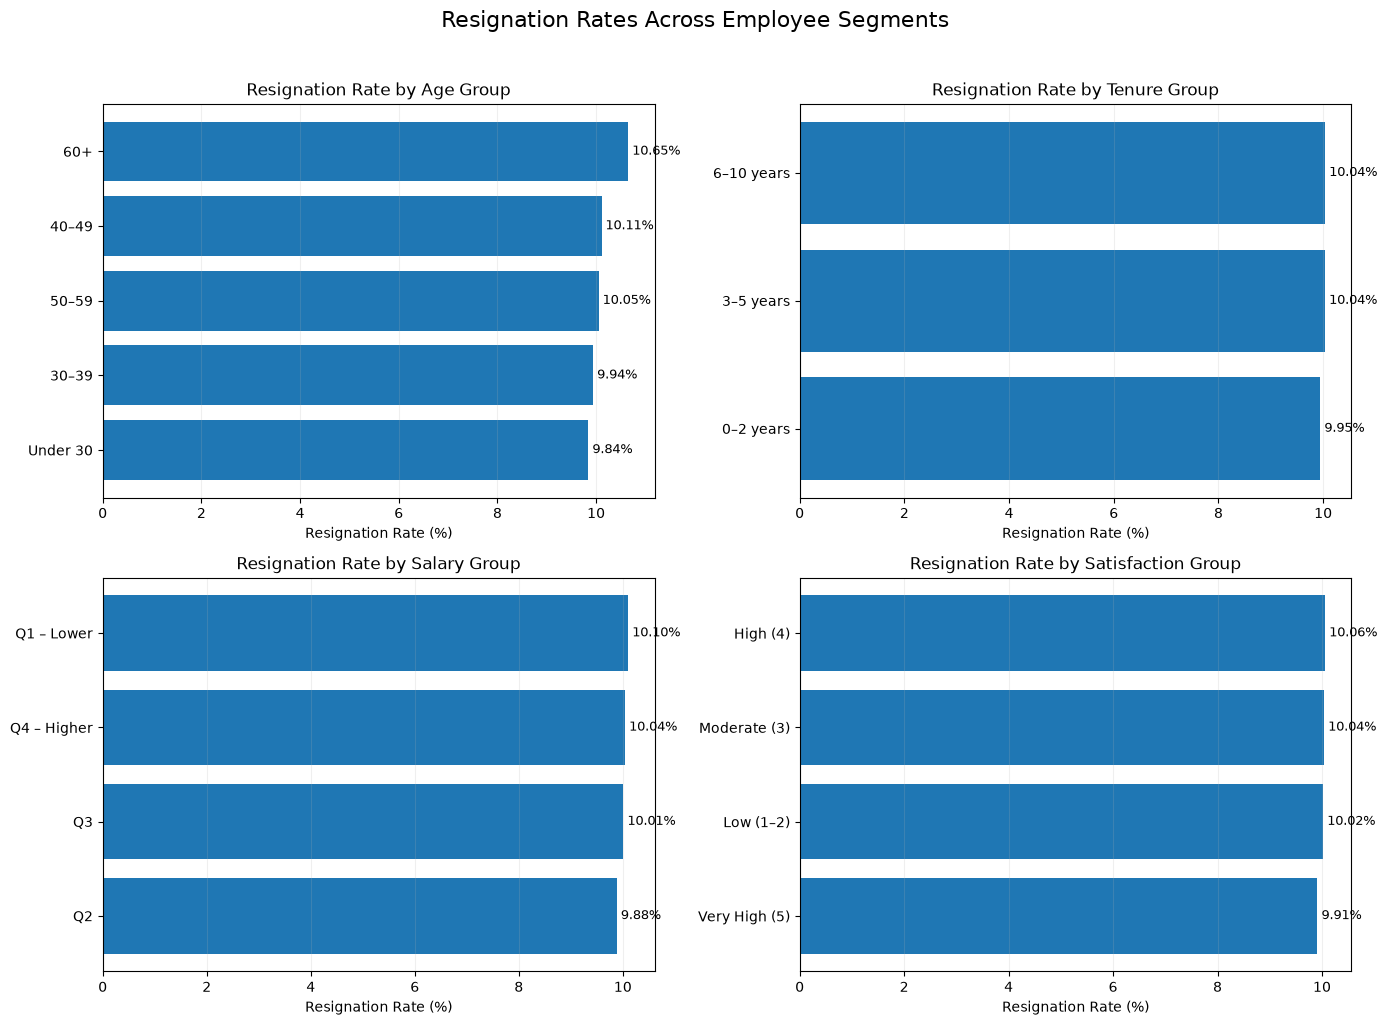

Chart saved to: ../visuals/4.4.8_attrition_rate_by_employee_segment.png


In [30]:
# 4.4.8 Attrition Rate by Employee Segment

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

segment_types = [
    ("Age", "Age Group"),
    ("Tenure", "Tenure Group"),
    ("Salary", "Salary Group"),
    ("Satisfaction", "Satisfaction Group")
]

for ax, (segment_type, title) in zip(axes.flatten(), segment_types):

    plot_data = (
        employee_segment_results[
            employee_segment_results["Segment_Type"] == segment_type
        ]
        .sort_values("Resignation_Rate")
    )

    ax.barh(
        plot_data["Segment"],
        plot_data["Resignation_Rate"]
    )

    ax.set_title(f"Resignation Rate by {title}")
    ax.set_xlabel("Resignation Rate (%)")
    ax.grid(axis="x", alpha=0.2)

    for y, value in enumerate(plot_data["Resignation_Rate"]):
        ax.text(
            value,
            y,
            f" {value:.2f}%",
            va="center",
            fontsize=9
        )

fig.suptitle(
    "Resignation Rates Across Employee Segments",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

# Save final visual
figure_path = VISUALS_DIR / "4.4.8_attrition_rate_by_employee_segment.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {figure_path}")

### 4.4.9 Statistical Association of Employee Segments with Attrition

Chi-square tests are applied to the derived employee segments to determine whether resignation status is statistically associated with age, tenure, salary, or satisfaction groups. Cramér's V is used to assess the strength of each association.

In [31]:
# 4.4.9 Statistical Association of Employee Segments with Attrition

from scipy.stats import chi2_contingency

employee_segment_variables = [
    "Age_Group",
    "Tenure_Group",
    "Salary_Group",
    "Satisfaction_Group"
]

segment_chi_square_results = []

for variable in employee_segment_variables:

    contingency_table = pd.crosstab(
        df[variable],
        df["Resigned"]
    )

    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(rows - 1, columns - 1))
    )

    segment_chi_square_results.append({
        "Segment": variable,
        "Chi_Square": chi2,
        "Degrees_of_Freedom": degrees_of_freedom,
        "P_Value": p_value,
        "Cramers_V": cramers_v,
        "Significant_At_0.05": p_value < 0.05
    })

segment_chi_square_results = pd.DataFrame(
    segment_chi_square_results
)

segment_chi_square_results.round(4)

,Segment,Chi_Square,Degrees_of_Freedom,P_Value,Cramers_V,Significant_At_0.05
0,Age_Group,2.2611,4,0.6879,0.0048,False
1,Tenure_Group,0.1964,2,0.9065,0.0014,False
2,Salary_Group,0.7301,3,0.8661,0.0027,False
3,Satisfaction_Group,0.3625,3,0.9479,0.0019,False


## 4.5 Statistical Analysis

The preceding analysis examined attrition through descriptive comparisons and individual workforce segments. This section extends the analysis by examining relationships between workforce characteristics and resignation using statistical methods.

The analysis will focus on identifying variables that provide evidence of association with resignation before progressing to multivariate modelling.

### 4.5.1 Correlation Analysis

Correlation analysis is used to examine the relationships among the continuous workforce variables included in the attrition analysis. The analysis provides an initial assessment of the direction and strength of relationships between workforce characteristics before multivariate modelling.

In [32]:
# 4.5.1 Correlation Analysis

continuous_variables = [
    "Age",
    "Years_At_Company",
    "Monthly_Salary",
    "Work_Hours_Per_Week",
    "Projects_Handled",
    "Overtime_Hours",
    "Sick_Days",
    "Training_Hours",
    "Promotions",
    "Performance_Score",
    "Employee_Satisfaction_Score"
]

correlation_matrix = df[continuous_variables].corr()

correlation_matrix.round(3)

,Age,Years_At_Company,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Training_Hours,Promotions,Performance_Score,Employee_Satisfaction_Score
Age,1.000,0.000,0.003,-0.003,-0.002,0.002,0.007,0.002,-0.003,0.002,-0.000
Years_At_Company,0.000,1.000,-0.001,0.003,0.003,0.002,-0.004,0.003,-0.003,0.002,-0.003
Monthly_Salary,0.003,-0.001,1.000,-0.002,-0.002,-0.003,0.004,-0.001,-0.002,0.510,0.001
Work_Hours_Per_Week,-0.003,0.003,-0.002,1.000,-0.004,0.006,-0.001,0.001,0.000,-0.006,0.001
Projects_Handled,-0.002,0.003,-0.002,-0.004,1.000,0.004,-0.005,0.002,-0.002,0.001,0.006
Overtime_Hours,0.002,0.002,-0.003,0.006,0.004,1.000,0.004,0.003,-0.003,-0.001,0.001
Sick_Days,0.007,-0.004,0.004,-0.001,-0.005,0.004,1.000,0.000,-0.003,0.003,-0.001
Training_Hours,0.002,0.003,-0.001,0.001,0.002,0.003,0.000,1.000,0.001,0.002,-0.001
Promotions,-0.003,-0.003,-0.002,0.000,-0.002,-0.003,-0.003,0.001,1.000,-0.004,0.000
Performance_Score,0.002,0.002,0.510,-0.006,0.001,-0.001,0.003,0.002,-0.004,1.000,0.002


### 4.5.2 Correlation Matrix Visualisation

A correlation heatmap is used to provide a visual representation of the relationships among the continuous workforce variables and to identify variables that may warrant further consideration in the multivariate analysis.

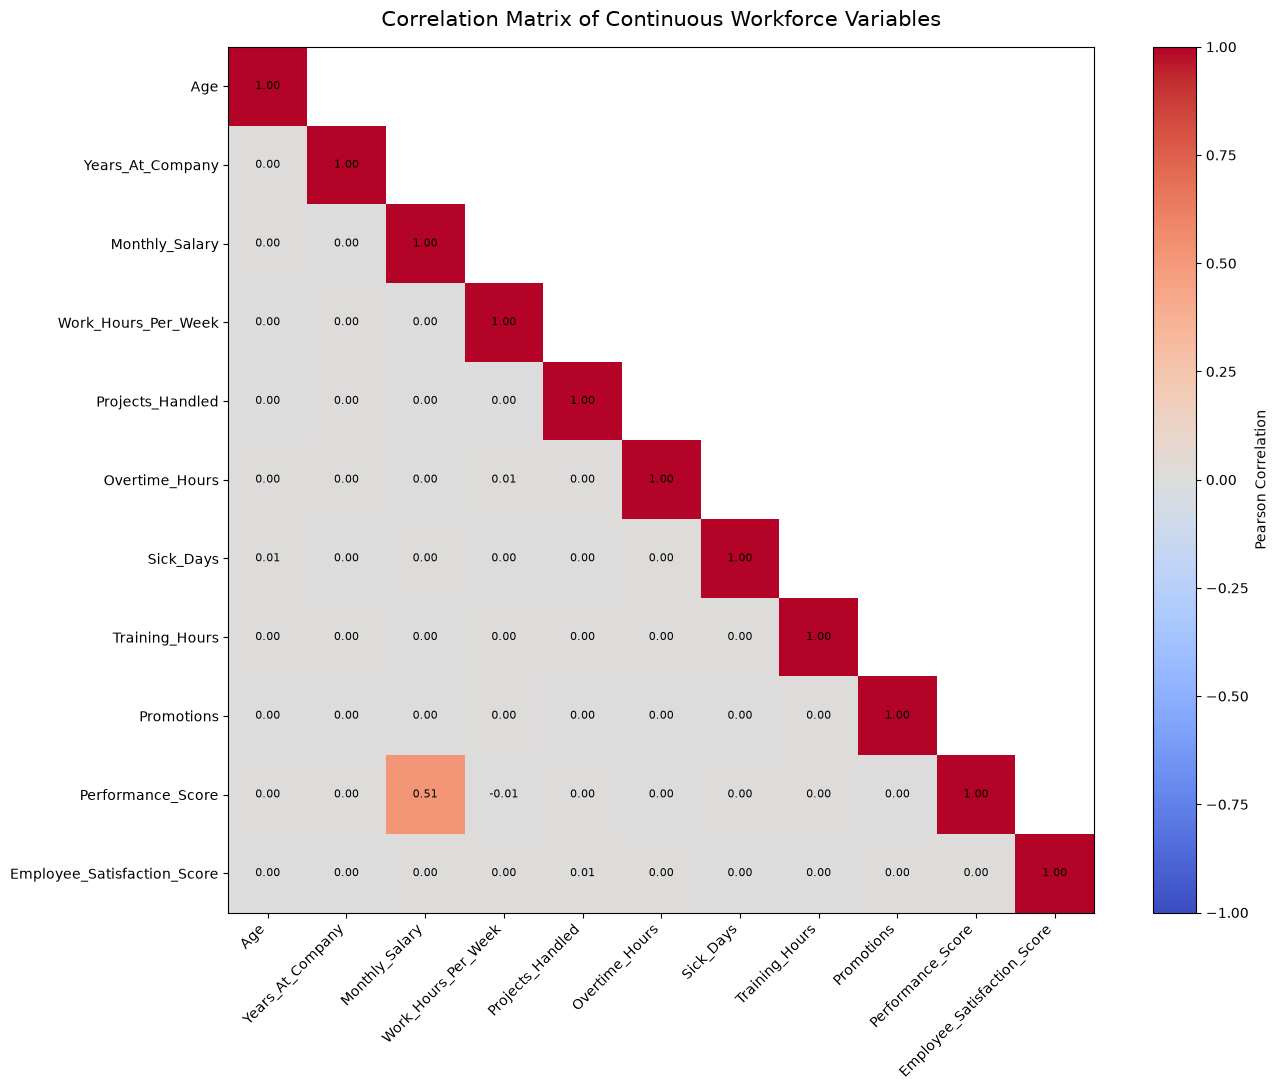

Chart saved to: ../visuals/4.5.2_correlation_matrix.png


In [33]:
# 4.5.2 Correlation Matrix Visualisation

import numpy as np
import matplotlib.pyplot as plt

# Create lower-triangle mask
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool),
    k=1
)

fig, ax = plt.subplots(figsize=(14, 11))

im = ax.imshow(
    np.ma.masked_where(mask, correlation_matrix),
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Axis labels
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_matrix.index)

# Add correlation values
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):

        if not mask[i, j]:

            value = correlation_matrix.iloc[i, j]

            # Prevent negative-zero display
            if abs(value) < 0.005:
                value = 0.00

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

ax.set_title(
    "Correlation Matrix of Continuous Workforce Variables",
    fontsize=15,
    pad=15
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson Correlation")

plt.tight_layout()

# Save final visual
figure_path = VISUALS_DIR / "4.5.2_correlation_matrix.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {figure_path}")

### 4.5.3 Correlation with Resignation

The resignation outcome is incorporated into the correlation analysis to assess the linear association between resignation status and the continuous workforce variables.

In [34]:
# 4.5.3 Correlation with Resignation

df["Resigned_Numeric"] = df["Resigned"].astype(int)

resignation_correlations = (
    df[continuous_variables + ["Resigned_Numeric"]]
    .corr()["Resigned_Numeric"]
    .drop("Resigned_Numeric")
    .sort_values()
    .to_frame("Correlation_with_Resignation")
)

resignation_correlations.round(4)

,Correlation_with_Resignation
Employee_Satisfaction_Score,-0.0028
Performance_Score,-0.0027
Projects_Handled,-0.0017
Monthly_Salary,-0.0015
Promotions,-0.0007
Work_Hours_Per_Week,0.0001
Years_At_Company,0.0008
Training_Hours,0.0012
Sick_Days,0.0017
Overtime_Hours,0.0024


### 4.5.4 Statistical Significance of Correlations

The correlations between continuous workforce variables and resignation are tested for statistical significance to determine whether the observed associations differ meaningfully from zero.

In [35]:
# 4.5.4 Statistical Significance of Correlations

from scipy.stats import pearsonr

correlation_significance = []

for variable in continuous_variables:

    r, p_value = pearsonr(
        df[variable],
        df["Resigned_Numeric"]
    )

    correlation_significance.append({
        "Variable": variable,
        "Correlation": r,
        "P_Value": p_value,
        "Significant_At_0.05": p_value < 0.05
    })

correlation_significance = (
    pd.DataFrame(correlation_significance)
    .sort_values("Correlation")
    .reset_index(drop=True)
)

correlation_significance.round(6)

,Variable,Correlation,P_Value,Significant_At_0.05
0,Employee_Satisfaction_Score,-0.002830,0.370853,False
1,Performance_Score,-0.002714,0.390695,False
2,Projects_Handled,-0.001713,0.587984,False
3,Monthly_Salary,-0.001524,0.629786,False
4,Promotions,-0.000743,0.814210,False
5,Work_Hours_Per_Week,0.000145,0.963413,False
6,Years_At_Company,0.000784,0.804132,False
7,Training_Hours,0.001172,0.710896,False
8,Sick_Days,0.001711,0.588507,False
9,Overtime_Hours,0.002383,0.451194,False


## 4.6 Multivariate Analysis

The preceding analyses examined workforce characteristics individually and assessed their association with resignation. This section considers multiple employee characteristics simultaneously to determine whether any variables remain associated with resignation after accounting for other factors.

### 4.6.1 Logistic Regression Model

A binary logistic regression model is developed to examine the relationship between employee characteristics and resignation status while controlling for the other variables included in the model.

The model includes demographic, employment, compensation, workload, development, performance, and satisfaction variables. Categorical workforce characteristics are encoded using indicator variables.

In [36]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [37]:
# 4.6.1 Logistic Regression Model

import pandas as pd
import statsmodels.api as sm

# Define predictors
numeric_predictors = [
    "Age",
    "Years_At_Company",
    "Monthly_Salary",
    "Work_Hours_Per_Week",
    "Projects_Handled",
    "Overtime_Hours",
    "Sick_Days",
    "Training_Hours",
    "Promotions",
    "Performance_Score",
    "Employee_Satisfaction_Score"
]

categorical_predictors = [
    "Department",
    "Job_Title",
    "Gender",
    "Education_Level",
    "Remote_Work_Frequency"
]

# Create modelling dataset
model_data = df[
    numeric_predictors + categorical_predictors + ["Resigned_Numeric"]
].copy()

# One-hot encode categorical predictors
model_data = pd.get_dummies(
    model_data,
    columns=categorical_predictors,
    drop_first=True,
    dtype=float
)

# Separate outcome and predictors
X = model_data.drop(columns="Resigned_Numeric")
y = model_data["Resigned_Numeric"]

# Add intercept
X = sm.add_constant(X)

# Fit logistic regression
logit_model = sm.Logit(y, X)
logit_results = logit_model.fit(
    maxiter=200,
    disp=False
)

# Display model summary
print(logit_results.summary())

                           Logit Regression Results                           
Dep. Variable:       Resigned_Numeric   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99965
Method:                           MLE   Df Model:                           34
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:               0.0003989
Time:                        04:40:28   Log-Likelihood:                -32517.
converged:                       True   LL-Null:                       -32530.
Covariance Type:            nonrobust   LLR p-value:                    0.8372
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -2.0903      0.322     -6.482      0.000      -2.722      -1.458
Age                             0.0010      0.001      1.112      0.266      -0.

### 4.6.2 Logistic Regression Results

The fitted logistic regression model is converted into an interpretable results table containing the regression coefficients, odds ratios, confidence intervals, and p-values for each predictor.

In [38]:
# 4.6.2 Logistic Regression Results

logistic_results = pd.DataFrame({
    "Variable": logit_results.params.index,
    "Coefficient": logit_results.params.values,
    "Odds_Ratio": np.exp(logit_results.params.values),
    "CI_Lower": np.exp(logit_results.conf_int()[0].values),
    "CI_Upper": np.exp(logit_results.conf_int()[1].values),
    "P_Value": logit_results.pvalues.values
})

logistic_results["Significant_At_0.05"] = (
    logistic_results["P_Value"] < 0.05
)

logistic_results = logistic_results.round({
    "Coefficient": 4,
    "Odds_Ratio": 4,
    "CI_Lower": 4,
    "CI_Upper": 4,
    "P_Value": 6
})

logistic_results

,Variable,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,P_Value,Significant_At_0.05
0,const,-2.0903,0.1237,0.0657,0.2326,0.000000,True
1,Age,0.0010,1.0010,0.9992,1.0029,0.266260,False
2,Years_At_Company,0.0009,1.0009,0.9937,1.0082,0.801300,False
3,Monthly_Salary,-0.0001,0.9999,0.9998,1.0001,0.543211,False
4,Work_Hours_Per_Week,0.0001,1.0001,0.9978,1.0024,0.943659,False
5,Projects_Handled,-0.0004,0.9996,0.9982,1.0011,0.607990,False
6,Overtime_Hours,0.0009,1.0009,0.9986,1.0033,0.438821,False
7,Sick_Days,0.0013,1.0013,0.9965,1.0061,0.592728,False
8,Training_Hours,0.0001,1.0001,0.9994,1.0008,0.724113,False
9,Promotions,-0.0032,0.9968,0.9719,1.0224,0.805608,False


### 4.6.3 Logistic Regression Model Performance

The overall performance of the logistic regression model is assessed using the likelihood-ratio test, McFadden's pseudo R-squared, log-likelihood, and classification accuracy.

In [39]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [41]:
# 4.6.3 Logistic Regression Model Performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predicted probabilities
predicted_probabilities = logit_results.predict(X)

# Convert probabilities to binary predictions
predicted_classes = (predicted_probabilities >= 0.50).astype(int)

# Model performance metrics
model_performance = pd.DataFrame({
    "Metric": [
        "Observations",
        "Log-Likelihood",
        "McFadden_Pseudo_R2",
        "LLR_P_Value",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ],
    "Value": [
        logit_results.nobs,
        logit_results.llf,
        logit_results.prsquared,
        logit_results.llr_pvalue,
        accuracy_score(y, predicted_classes),
        precision_score(y, predicted_classes, zero_division=0),
        recall_score(y, predicted_classes, zero_division=0),
        f1_score(y, predicted_classes, zero_division=0),
        roc_auc_score(y, predicted_probabilities)
    ]
})

model_performance

,Metric,Value
0,Observations,100000.000000
1,Log-Likelihood,-32517.288398
2,McFadden_Pseudo_R2,0.000399
3,LLR_P_Value,0.837240
4,Accuracy,0.899900
5,Precision,0.000000
6,Recall,0.000000
7,F1_Score,0.000000
8,ROC_AUC,0.515581


### 4.6.4 ROC Curve

The Receiver Operating Characteristic (ROC) curve is used to evaluate the model's ability to distinguish between employees who resigned and those who remained across different classification thresholds.

The area under the ROC curve (ROC-AUC) provides a threshold-independent measure of the model's discriminatory performance.

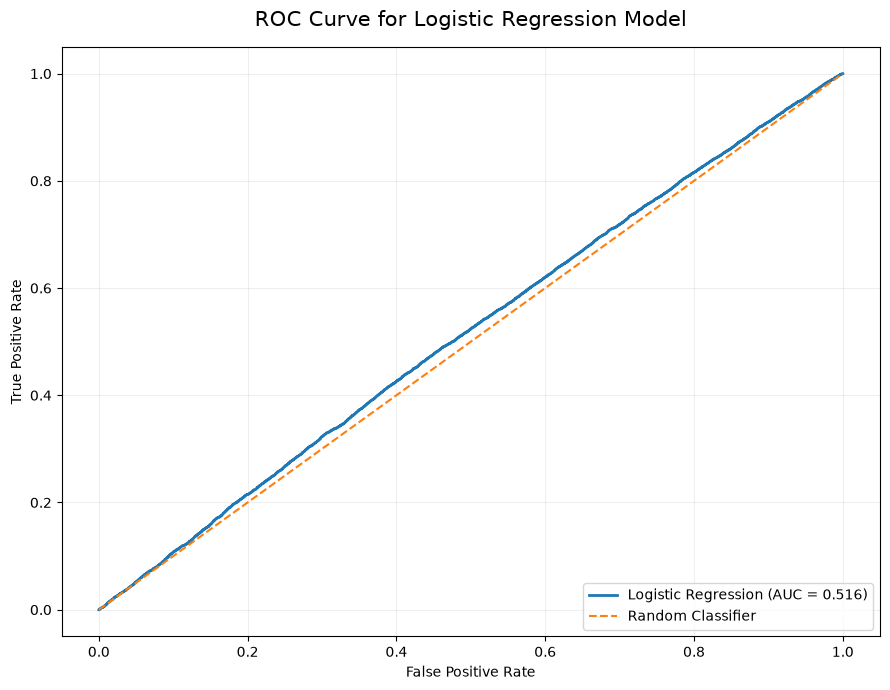

ROC-AUC: 0.5156
Chart saved to: ../visuals/4.6.4_roc_curve.png


In [42]:
# 4.6.4 ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y,
    predicted_probabilities
)

roc_auc = roc_auc_score(
    y,
    predicted_probabilities
)

# Create ROC curve
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Random classifier reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

ax.set_title(
    "ROC Curve for Logistic Regression Model",
    fontsize=15,
    pad=15
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()

figure_path = VISUALS_DIR / "4.6.4_roc_curve.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Chart saved to: {figure_path}")

### 4.6.5 Confusion Matrix

The confusion matrix is used to examine the classification outcomes produced by the logistic regression model at the 0.50 probability threshold.

This provides a direct view of correctly and incorrectly classified resigned and retained employees and complements the aggregate classification metrics reported above.

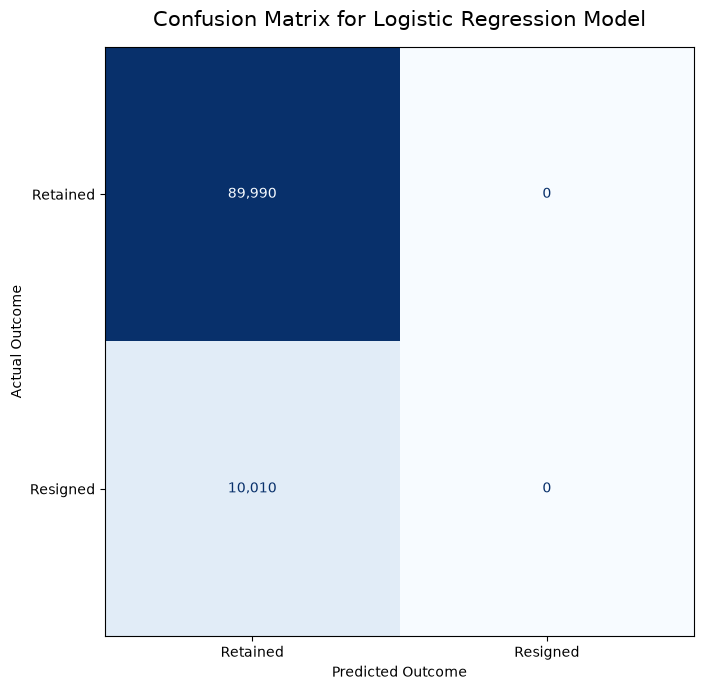

Confusion Matrix:
[[89990     0]
 [10010     0]]
Chart saved to: ../visuals/4.6.5_confusion_matrix.png


In [43]:
# 4.6.5 Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(
    y,
    predicted_classes
)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Resigned"]
)

disp.plot(
    ax=ax,
    values_format=",d",
    cmap="Blues",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix for Logistic Regression Model",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")

plt.tight_layout()

figure_path = VISUALS_DIR / "4.6.5_confusion_matrix.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion Matrix:")
print(cm)
print(f"Chart saved to: {figure_path}")

### 4.6.6 Precision–Recall Curve

Because resignation represents a minority outcome in the workforce, precision and recall provide an important complementary assessment of model performance.

The precision–recall curve evaluates the trade-off between correctly identifying resigned employees and the proportion of predicted resignations that are correct across different classification thresholds. Average precision is also reported as a threshold-independent summary of this performance.

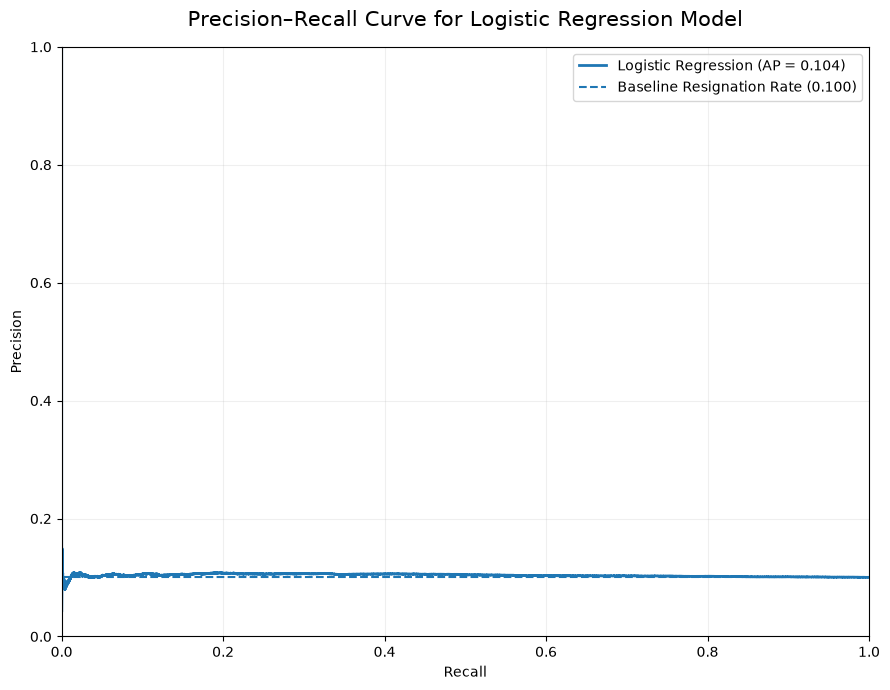

Average Precision: 0.1039
Baseline Resignation Rate: 0.1001
Chart saved to: ../visuals/4.6.6_precision_recall_curve.png


In [44]:
# 4.6.6 Precision–Recall Curve

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# Calculate precision-recall values
precision, recall, thresholds_pr = precision_recall_curve(
    y,
    predicted_probabilities
)

# Calculate average precision
average_precision = average_precision_score(
    y,
    predicted_probabilities
)

# Create precision-recall curve
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Logistic Regression (AP = {average_precision:.3f})"
)

# Baseline prevalence
baseline_prevalence = y.mean()

ax.axhline(
    baseline_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline Resignation Rate ({baseline_prevalence:.3f})"
)

ax.set_title(
    "Precision–Recall Curve for Logistic Regression Model",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(
    loc="upper right"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()

figure_path = VISUALS_DIR / "4.6.6_precision_recall_curve.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Average Precision: {average_precision:.4f}")
print(f"Baseline Resignation Rate: {baseline_prevalence:.4f}")
print(f"Chart saved to: {figure_path}")

### 4.6.7 Classification Threshold Analysis

The default 0.50 classification threshold results in all observations being classified as retained. To assess whether alternative probability thresholds provide more useful classification behaviour, model performance is evaluated across a range of thresholds.

Accuracy, precision, recall, and F1-score are compared to identify the trade-off between correctly identifying resigned employees and limiting false-positive classifications.

In [45]:
# 4.6.7 Classification Threshold Analysis

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    threshold_predictions = (
        predicted_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y,
            threshold_predictions
        ),
        "Precision": precision_score(
            y,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y,
            threshold_predictions,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y,
            threshold_predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,Threshold,Accuracy,Precision,Recall,F1_Score
0,0.05,0.1001,0.1001,1.0000,0.1820
1,0.10,0.4912,0.1042,0.5374,0.1745
2,0.15,0.8999,0.0000,0.0000,0.0000
3,0.20,0.8999,0.0000,0.0000,0.0000
4,0.25,0.8999,0.0000,0.0000,0.0000
5,0.30,0.8999,0.0000,0.0000,0.0000
6,0.35,0.8999,0.0000,0.0000,0.0000
7,0.40,0.8999,0.0000,0.0000,0.0000
8,0.45,0.8999,0.0000,0.0000,0.0000
9,0.50,0.8999,0.0000,0.0000,0.0000


### 4.6.8 Classification Performance Across Thresholds

Classification performance is visualised across probability thresholds to illustrate the trade-offs between accuracy, precision, recall, and F1-score.

This provides a clearer assessment of how the model behaves under alternative decision thresholds rather than relying solely on the default 0.50 threshold.

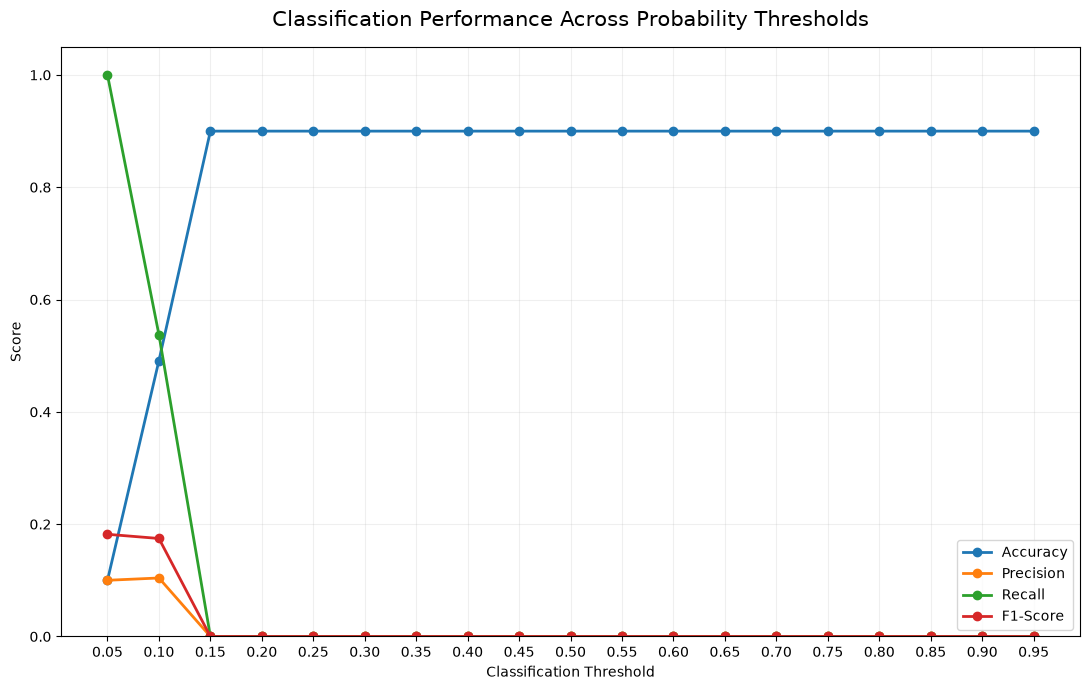

Chart saved to: ../visuals/4.6.8_classification_performance_by_threshold.png


In [46]:
# 4.6.8 Classification Performance Across Thresholds

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Accuracy"],
    marker="o",
    linewidth=2,
    label="Accuracy"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    linewidth=2,
    label="Recall"
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["F1_Score"],
    marker="o",
    linewidth=2,
    label="F1-Score"
)

ax.set_title(
    "Classification Performance Across Probability Thresholds",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")

ax.set_ylim(0, 1.05)
ax.set_xticks(threshold_results["Threshold"])

ax.legend(
    loc="best"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()

figure_path = VISUALS_DIR / "4.6.8_classification_performance_by_threshold.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved to: {figure_path}")

### 4.6.9 Out-of-Sample Model Validation

The logistic regression model is evaluated on a held-out test set to assess whether its predictive performance generalises beyond the observations used during model estimation.

A stratified train-test split is used to preserve the proportion of resigned employees in both datasets. Performance is assessed using accuracy, precision, recall, F1-score, ROC-AUC, and average precision.

In [47]:
# 4.6.9 Out-of-Sample Model Validation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Define predictors and outcome
X_raw = df[
    numeric_predictors + categorical_predictors
].copy()

y_raw = df["Resigned_Numeric"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    stratify=y_raw,
    random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_predictors
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_predictors
        )
    ]
)

# Logistic regression pipeline
validation_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=2000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

# Fit model on training data
validation_model.fit(
    X_train,
    y_train
)

# Test-set predicted probabilities
test_probabilities = validation_model.predict_proba(
    X_test
)[:, 1]

# Default 0.50 classification threshold
test_predictions = (
    test_probabilities >= 0.50
).astype(int)

# Calculate validation metrics
validation_performance = pd.DataFrame({
    "Metric": [
        "Training Observations",
        "Test Observations",
        "Test Resignation Rate",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC",
        "Average_Precision"
    ],
    "Value": [
        len(X_train),
        len(X_test),
        y_test.mean(),
        accuracy_score(y_test, test_predictions),
        precision_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            test_probabilities
        ),
        average_precision_score(
            y_test,
            test_probabilities
        )
    ]
})

validation_performance

,Metric,Value
0,Training Observations,80000.000000
1,Test Observations,20000.000000
2,Test Resignation Rate,0.100100
3,Accuracy,0.899900
4,Precision,0.000000
5,Recall,0.000000
6,F1_Score,0.000000
7,ROC_AUC,0.491686
8,Average_Precision,0.097641


## 4.7 Business Interpretation

The analysis has examined workforce composition, employee characteristics, departmental variation, resignation patterns, statistical associations, and multivariate relationships. This section consolidates the evidence into a coherent interpretation of workforce stability and attrition.

The interpretation distinguishes between descriptive patterns, statistically supported relationships, and predictive performance. Findings are treated as associations within the observed dataset and are not interpreted as causal relationships.

### 4.7.1 Workforce Structure and Operating Environment

The workforce is highly balanced across departments and job titles, with relatively little variation in the overall organisational structure. Gender representation is also broadly balanced, while educational attainment is concentrated in Bachelor and High School qualifications.

Department-level averages show similarly limited variation in tenure, salary, working hours, workload, training, performance, and satisfaction. This indicates that broad organisational averages provide a relatively consistent picture of workforce conditions across departments.

The implication is that workforce-level or departmental summaries alone are unlikely to explain meaningful differences in employee outcomes. More detailed employee-level and subgroup analysis is therefore required when investigating workforce stability.

### 4.7.2 Attrition Patterns

A total of 10,010 employees resigned, representing 10.01% of the workforce. However, resignation rates remain remarkably consistent across the workforce segments examined.

Department, job title, gender, education level, and remote-work frequency showed no statistically significant association with resignation based on the chi-square tests. The corresponding Cramér's V values were also extremely small, indicating negligible association strength.

Similarly, segmentation by age, tenure, salary, and employee satisfaction produced resignation rates that remained close to the overall workforce rate. None of these segmented characteristics showed a statistically significant association with resignation.

These results indicate that attrition is not concentrated strongly within any of the broad workforce segments available in the dataset.

### 4.7.3 Resigned Versus Retained Employees

Direct comparison of resigned and retained employees also produced highly similar average values across age, tenure, salary, working hours, projects handled, overtime, sick days, training, promotions, performance, and satisfaction.

Independent-samples t-tests found no statistically significant differences between the two groups across the continuous workforce variables examined. Effect-size analysis further showed that the standardised differences were negligible.

Taken together, the descriptive, significance-testing, and effect-size results provide consistent evidence that the observed workforce characteristics do not meaningfully distinguish resigned employees from retained employees in this dataset.

### 4.7.4 Relationships Between Workforce Characteristics

Correlation analysis found very weak relationships among almost all continuous workforce variables. The principal exception was the relationship between monthly salary and performance score, which showed a moderate positive correlation of approximately 0.51.

However, the continuous workforce variables showed correlations with resignation that were all extremely close to zero. None of these correlations was statistically significant.

This suggests that the available numerical workforce measures provide limited evidence of a linear relationship with resignation. The findings also reinforce the importance of distinguishing relationships between employee characteristics from relationships with the business outcome itself.

### 4.7.5 Multivariate Evidence and Predictive Value

The logistic regression analysis provides further evidence that the available workforce characteristics have limited explanatory value for resignation.

The overall model produced a McFadden pseudo R-squared of 0.000399 and a likelihood-ratio test p-value of 0.837. The model therefore provides very limited improvement over the null model.

Model discrimination was similarly weak. The ROC-AUC was approximately 0.516 on the full dataset and approximately 0.492 on the held-out test set. Average precision was 0.104 on the full dataset compared with a baseline resignation rate of 0.100, and 0.098 on the held-out test set.

At the default 0.50 classification threshold, the model classified all employees as retained, resulting in an accuracy of 89.99% but zero precision, recall, and F1-score for the resignation class. Threshold analysis showed that lowering the threshold increased recall but did not produce evidence of strong overall classification performance.

The out-of-sample results are particularly important because they indicate that the weak predictive performance observed in the full dataset does not translate into useful generalisation to unseen employees.

Consequently, the model should not be treated as a reliable employee-level resignation risk prediction tool based on the variables available in this dataset.

### 4.7.6 Overall Business Interpretation

The combined evidence points to a relatively uniform workforce environment in which resignation occurs at a rate of 10.01% but is not strongly differentiated by the demographic, organisational, compensation, workload, development, performance, or satisfaction variables available in the dataset.

The consistency of the findings across descriptive comparisons, statistical tests, effect sizes, correlation analysis, logistic regression, threshold analysis, and out-of-sample validation strengthens this conclusion.

The results should not be interpreted to mean that these factors are universally unrelated to employee retention. Rather, within this dataset and the variables measured, there is insufficient evidence to identify strong relationships with resignation.

From an HR management perspective, this means that broad interventions targeted solely at particular departments, demographic groups, salary bands, tenure groups, or satisfaction categories would not be strongly supported by the evidence produced in this analysis.

The more important analytical implication is that meaningful drivers of resignation may lie outside the variables captured in the dataset. Factors such as career progression opportunities, manager relationships, organisational culture, workload quality, recognition, benefits, commuting conditions, labour-market opportunities, employee experience, and reasons for leaving are not sufficiently represented in the available data and therefore cannot be evaluated directly.

The analysis therefore provides stronger evidence about what the organisation cannot confidently explain from the available data than about a specific cause of resignation. This is itself an important workforce-analytics finding because it identifies a limitation in the organisation's current analytical information base.

## 4.8 Recommendations and Management Implications

The findings provide limited evidence that resignation is concentrated within any particular demographic, departmental, compensation, tenure, workload, performance, or satisfaction segment. Recommendations are therefore focused on strengthening workforce intelligence, improving retention monitoring, and addressing information gaps rather than targeting specific employee groups without supporting evidence.

### 4.8.1 Strengthen Employee Exit and Experience Data

The limited explanatory and predictive power of the available variables indicates that important drivers of resignation may not be captured in the current workforce dataset.

HR should strengthen the collection of structured exit information, including primary reason for leaving, manager relationship, career-development opportunities, compensation competitiveness, workload concerns, organisational culture, benefits, and external employment factors.

Where appropriate, employee-experience surveys should also be incorporated into workforce analytics so that retention analysis can move beyond basic demographic and employment characteristics.

### 4.8.2 Monitor Attrition Continuously Rather Than Targeting Broad Segments

Because resignation rates were broadly consistent across the workforce segments examined, broad retention interventions targeted solely at particular departments, demographic groups, salary bands, or tenure categories are not strongly supported by the evidence.

HR should instead establish regular attrition monitoring using department, role, tenure, compensation, workload, performance, satisfaction, and other relevant employee-experience indicators. Changes in these measures over time can then be investigated when meaningful deviations emerge.

### 4.8.3 Develop a More Complete Workforce Analytics Framework

The analysis demonstrates the value of combining descriptive, statistical, and predictive methods, but it also highlights the limitations of relying on a narrow set of employee characteristics.

A more complete workforce analytics framework should integrate HR records with employee engagement measures, career progression, manager and team information, benefits, absenteeism, performance history, internal mobility, and structured exit data where available.

This would allow future analysis to investigate workforce stability using a broader representation of the employee experience.

### 4.8.4 Use Predictive Models Only When Sufficient Evidence Exists

The logistic regression model demonstrated limited discriminatory and predictive performance, including weak out-of-sample performance. It should therefore not be used as an employee-level resignation risk scoring mechanism in its current form.

Future predictive modelling should only be introduced when richer and more informative workforce variables become available and when models demonstrate acceptable performance on unseen data.

Any future employee-risk model should also be subject to appropriate validation, monitoring, fairness assessment, and governance before being considered for operational HR decision-making.

### 4.8.5 Establish Evidence-Based Retention Reviews

HR leadership should use the current 10.01% resignation rate as a baseline for ongoing workforce monitoring rather than treating it as evidence of a specific underlying cause.

Periodic retention reviews should examine whether resignation rates, employee experience measures, and workforce conditions are changing over time. Where material changes occur, targeted investigation can then be undertaken using both quantitative workforce data and qualitative employee feedback.

This approach reduces the risk of implementing broad retention initiatives without sufficient evidence and creates a stronger foundation for future workforce planning.

### 4.8.6 Management Implication

The principal management implication is that the organisation should strengthen its workforce intelligence before making highly targeted retention decisions.

The analysis does not identify a single demographic, department, compensation level, tenure group, or employee characteristic that can reliably explain resignation. Instead, it demonstrates the importance of improving the breadth and quality of workforce information available to HR.

Management should therefore prioritise better employee-experience measurement, structured exit-data collection, continuous attrition monitoring, and responsible use of predictive analytics. This would create a stronger evidence base for identifying emerging workforce risks and designing targeted interventions when meaningful patterns become visible.